In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("headbrain.csv")

In [3]:
df.shape

(237, 4)

In [4]:
df.head()

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [5]:
x=df['Head Size(cm^3)'].values
y=df['Brain Weight(grams)'].values

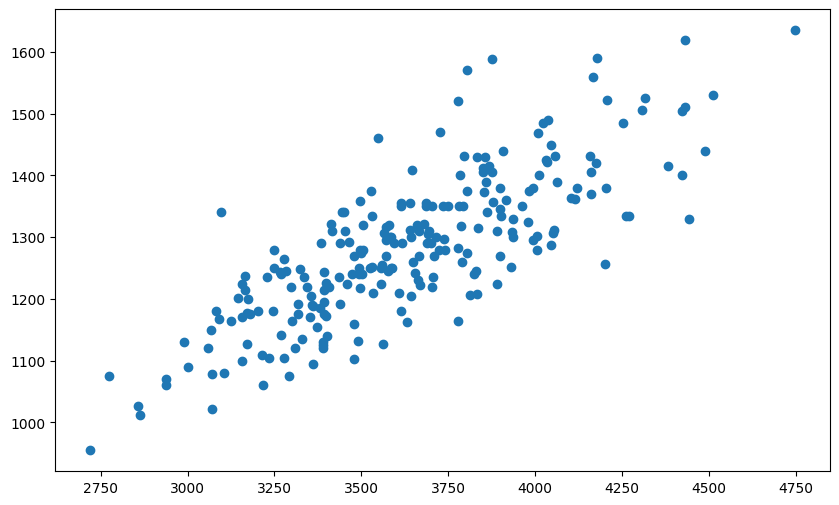

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.show()

In [7]:
mean_x=np.mean(x)
mean_y=np.mean(y)

In [8]:
print(mean_x)
print(mean_y)

3633.9915611814345
1282.873417721519


In [10]:
numer=0
denom=0
n=len(x)

for i in range(n):
    numer += (y[i] - mean_y)*(x[i] -mean_x)
    denom += (x[i] -mean_x) ** 2

slope =numer/denom
intercept =mean_y - slope * mean_x
print("Slope : ", slope)
print("intercept :", intercept)

Slope :  0.26342933948939945
intercept : 325.57342104944223


In [11]:
predictions = []
for i in range(n):
    y_pred = slope*x[i] + intercept
    predictions.append(int(y_pred))

In [12]:
print("Prediction : ",predictions[:5])
print("Actual : ", y[:5])

Prediction :  [1514, 1310, 1448, 1320, 1425]
Actual :  [1530 1297 1335 1282 1590]


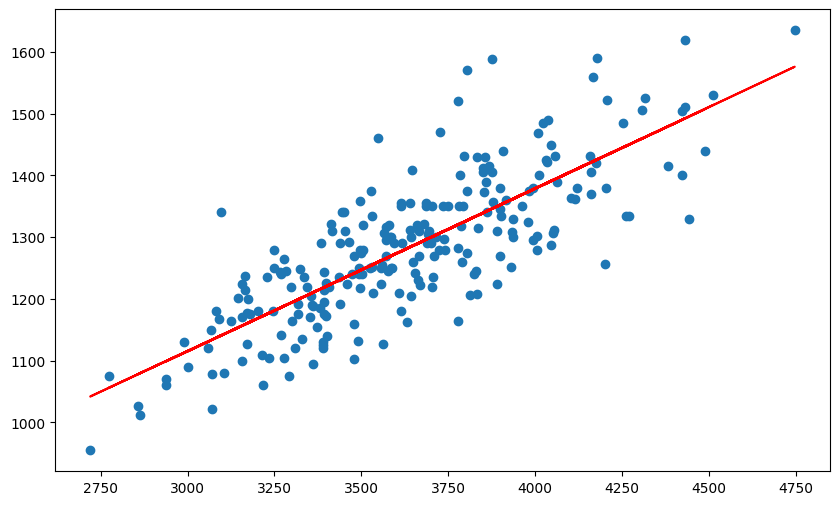

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.plot(x,predictions, 'r')
plt.show()

In [14]:
error = 0
for i in range(n):
    error += (predictions[i] - y[i]) **2

mse = error / n 
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))

MSE : 5202.9029535864975
RMSE : 72.13115106239812


Gradient Descent

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
x=np.reshape(x,(-1,1))
y=np.reshape(y,(-1,1))

minmax=MinMaxScaler()
scaled_x = minmax.fit_transform(x)
scaled_y = minmax.fit_transform(y)

In [17]:
scaled_x[:5]

array([[0.88406512],
       [0.50222003],
       [0.7602368 ],
       [0.52146029],
       [0.71879625]])

In [18]:
def gradient_descent(epochs, alpha):
    slope, inter = 0, 0
    
    for i in range(epochs):
        y_pred = scaled_x * slope + inter
        loss = y_pred - scaled_y
        gradSlope = (2/n) * np.dot(loss.T, scaled_x)
        gradInter = (2/n) * np.sum(loss)
        slope = slope - gradSlope * alpha
        inter = inter - gradInter * alpha
    
    return slope, inter


In [23]:
epochs = 100
alpha = 0.01
slope, inter = gradient_descent(epochs, alpha)
print("Slope :", slope)
print("Intercept :", inter)

Slope : [[0.20252986]]
Intercept : 0.3555123649132354


In [24]:
predictions = []
for i in range(n):
    y_pred = slope[0][0]*scaled_x[i] + inter
    predictions.append((y_pred))

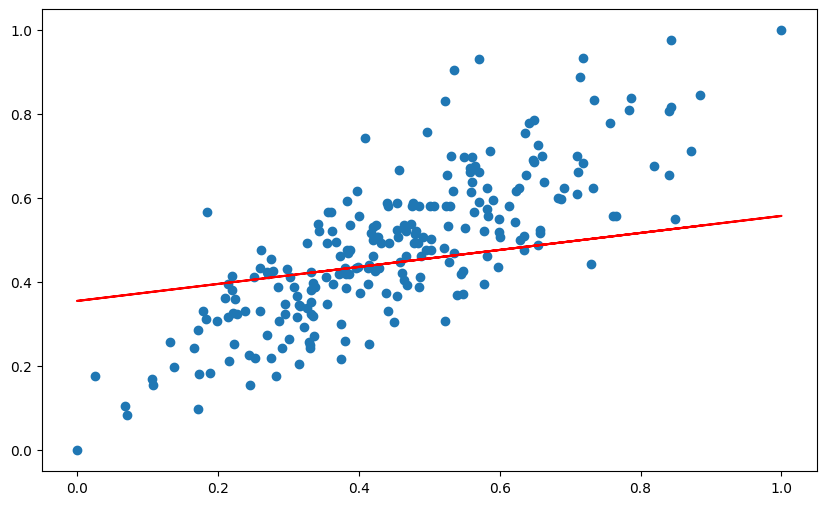

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(scaled_x,scaled_y)
plt.plot(scaled_x,predictions, 'r')
plt.show()